# Cochleagram

This notebook computes a cochleagram from a short synthetic signal and plots the compressed cochlear envelopes.


> Run these notebooks from an environment where the local extension is installed:
>
> ```bash
> python -m pip install maturin notebook matplotlib
> maturin develop
> jupyter notebook notebooks
> ```

In [1]:
import math

import matplotlib.pyplot as plt
import spafe

In [2]:
signal_size = 4096
sr = 16_000
signal = [
    math.sin(2.0 * math.pi * 440.0 * idx / sr)
    for idx in range(signal_size)
]

opts = spafe.CochleagramOptions(
    signal_size=signal_size,
    sr=sr,
    env_sr=400,
    filter_n=16,
    low_lim=50.0,
    high_lim=6_000.0,
    sample_factor=2,
    downsampling_window_size=129,
    compression="power",
)

In [3]:
output = spafe.cochleagram(signal, opts)
print(f"cochleagram shape: {len(output.cochleagram)} x {len(output.cochleagram[0])}")
print("first center frequencies:", [round(value, 3) for value in output.center_freqs[:8]])

cochleagram shape: 37 x 100
first center frequencies: [25.653, 50.0, 76.676, 105.903, 137.927, 173.014, 211.458, 253.58]


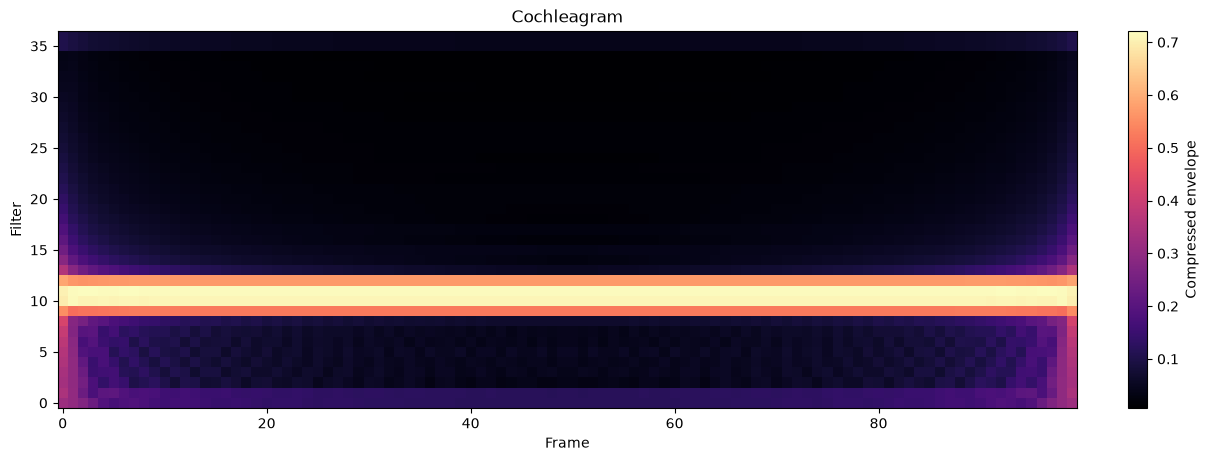

In [4]:
fig, ax = plt.subplots(figsize=(12, 4.5), constrained_layout=True)
image = ax.imshow(output.cochleagram, aspect="auto", origin="lower", cmap="magma")
ax.set_title("Cochleagram")
ax.set_xlabel("Frame")
ax.set_ylabel("Filter")
fig.colorbar(image, ax=ax, label="Compressed envelope")
plt.show()

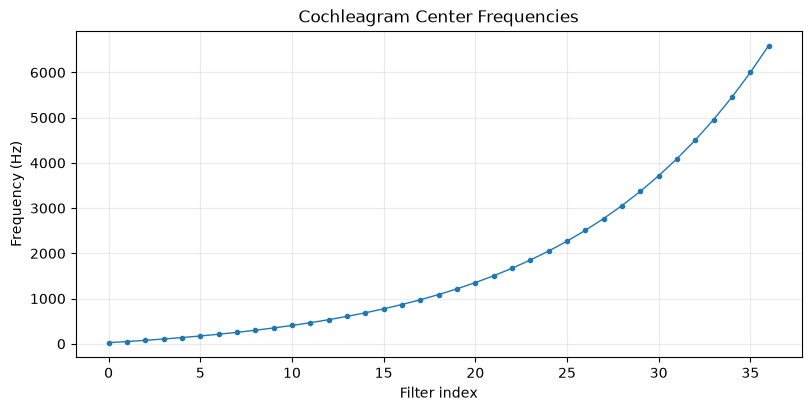

In [5]:
fig, ax = plt.subplots(figsize=(8, 4), constrained_layout=True)
ax.plot(output.center_freqs, marker="o", markersize=3, linewidth=1.0)
ax.set_title("Cochleagram Center Frequencies")
ax.set_xlabel("Filter index")
ax.set_ylabel("Frequency (Hz)")
ax.grid(True, alpha=0.25)
plt.show()